# Fake News Detection
**Name:** Abdirahman Yussuf

**Group:** Group 2B

In [52]:
# Import basic libraries
import pandas as pd  
import numpy as np  
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter
import io

# Import NLP tools and NLTK library modules
import nltk 
from nltk.corpus import stopwords, wordnet 
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer 
from nltk import pos_tag  
from nltk.util import bigrams
from nltk.util import trigrams
import string  
import re 
import spacy

# Import scikit-learn library's classes, tools, and modules 
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder 
from sklearn.model_selection import train_test_split, cross_val_score 
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score, precision_score, recall_score, auc, roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
import joblib
from gensim.models import Word2Vec

# Import tensorflow, and keras modules
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import TextVectorization, Embedding, GlobalAveragePooling1D
from tensorflow.keras.layers import Dropout, Dense, LSTM, Input, Masking

# Import transformers and pytorch modules
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
import torch
from torch.utils.data import Dataset


# Disable warnings
import warnings
warnings.filterwarnings('ignore')

In [53]:
df = pd.read_csv('../dataset/data.csv')
df.head(5)

,news_url,title,extracted_article_text,news_type,class
0,https://www.bustle.com/p/will-the-royals-retur...,Will 'The Royals' Return For Season 5? This St...,Entertainment With a royal wedding and a coup ...,gossip,1
1,https://www.foxnews.com/entertainment/naya-riv...,Naya Rivera refiles for divorce from Ryan Dors...,"This material may not be published, broadcast,...",gossip,1
2,https://www.unitedbypop.com/style/fashion/tayl...,Outfit ideas for Taylor Swift's Reputation Tour,United By Pop - United Kingdom. United States....,gossip,1
3,https://variety.com/2018/music/news/scott-hutc...,Scott Hutchison Dead: Frightened Rabbit Frontm...,By Robert Mitchell A body found Thursday night...,gossip,1
4,https://www.etonline.com/kate-middleton-gives-...,Kate Middleton Gives Birth to Royal Baby No. 3...,Baby No. 3 is officially here! Kate Middleton ...,gossip,1


In [54]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text


In [55]:
df['clean_text'] = df['extracted_article_text'].astype(str).apply(clean_text)
df[['extracted_article_text', 'clean_text']].head()


,extracted_article_text,clean_text
0,Entertainment With a royal wedding and a coup ...,entertainment with a royal wedding and a coup ...
1,"This material may not be published, broadcast,...",this material may not be published broadcast r...
2,United By Pop - United Kingdom. United States....,united by pop united kingdom united states uni...
3,By Robert Mitchell A body found Thursday night...,by robert mitchell a body found thursday night...
4,Baby No. 3 is officially here! Kate Middleton ...,baby no is officially here kate middleton and ...


In [56]:
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    return ' '.join([word for word in text.split() if word not in stop_words])


In [57]:
df['clean_text'] = df['clean_text'].apply(remove_stopwords)


In [58]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    return ' '.join([lemmatizer.lemmatize(word) for word in text.split()])


In [59]:
df['clean_text'] = df['clean_text'].apply(lemmatize_text)

In [60]:
df[['extracted_article_text', 'clean_text']].head(10)


,extracted_article_text,clean_text
0,Entertainment With a royal wedding and a coup ...,entertainment royal wedding coup occurring sea...
1,"This material may not be published, broadcast,...",material may published broadcast rewritten red...
2,United By Pop - United Kingdom. United States....,united pop united kingdom united state united ...
3,By Robert Mitchell A body found Thursday night...,robert mitchell body found thursday night miss...
4,Baby No. 3 is officially here! Kate Middleton ...,baby officially kate middleton prince william ...
5,"""It's so fun to see how they all interact and ...",fun see interact connect khloé kardashian shar...
6,Lena Dunham's beloved cat Gia Marie died in he...,lena dunhams beloved cat gia marie died arm th...
7,Country star Tim McGraw collapsed on stage dur...,country star tim mcgraw collapsed stage perfor...
8,Hollywood Boulevard was shutdown at Highland T...,hollywood boulevard shutdown highland thursday...
9,By DAILYMAIL.COM REPORTER Published: 14:49 BST...,dailymailcom reporter published bst may update...


### TF-IDF Vectorization

In [61]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)  # You can change features
X_tfidf = tfidf.fit_transform(df['clean_text'])


### Tokenizer and  Padding 

In [62]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
tokenizer = Tokenizer(num_words=5000, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean_text'])
sequences = tokenizer.texts_to_sequences(df['clean_text'])
padded_sequences = pad_sequences(sequences, padding='post', maxlen=100)


### Tokenization for BERT

In [63]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
encoding = tokenizer(
    list(df['clean_text']),
    truncation=True,
    padding=True,
    max_length=300,
    return_tensors='pt'
)


#### Encoding Features

To prepare our clean text for model training, we use the `BertTokenizer` to convert each sentence into:

- **`input_ids`**: Numerical token IDs representing each word/token.
- **`attention_mask`**: Binary values indicating which tokens are real (1) and which are just padding (0).

These are essential for transformer models like BERT, which do not understand raw text directly. Instead, they process sequences of token IDs.

We store `input_ids` and `attention_mask` as new columns in our dataframe:


In [64]:
df['input_ids'] = encoding['input_ids'].tolist()
df['attention_mask'] = encoding['attention_mask'].tolist()


In [65]:
df.columns


Index(['news_url', 'title', 'extracted_article_text', 'news_type', 'class',
       'clean_text', 'input_ids', 'attention_mask'],
      dtype='object')

In [66]:
df.head(10)

,news_url,title,extracted_article_text,news_type,class,clean_text,input_ids,attention_mask
0,https://www.bustle.com/p/will-the-royals-retur...,Will 'The Royals' Return For Season 5? This St...,Entertainment With a royal wedding and a coup ...,gossip,1,entertainment royal wedding coup occurring sea...,"[101, 4024, 2548, 5030, 8648, 10066, 2161, 959...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,https://www.foxnews.com/entertainment/naya-riv...,Naya Rivera refiles for divorce from Ryan Dors...,"This material may not be published, broadcast,...",gossip,1,material may published broadcast rewritten red...,"[101, 3430, 2089, 2405, 3743, 2128, 15773, 241...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,https://www.unitedbypop.com/style/fashion/tayl...,Outfit ideas for Taylor Swift's Reputation Tour,United By Pop - United Kingdom. United States....,gossip,1,united pop united kingdom united state united ...,"[101, 2142, 3769, 2142, 2983, 2142, 2110, 2142...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,https://variety.com/2018/music/news/scott-hutc...,Scott Hutchison Dead: Frightened Rabbit Frontm...,By Robert Mitchell A body found Thursday night...,gossip,1,robert mitchell body found thursday night miss...,"[101, 2728, 6395, 2303, 2179, 9432, 2305, 4394...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,https://www.etonline.com/kate-middleton-gives-...,Kate Middleton Gives Birth to Royal Baby No. 3...,Baby No. 3 is officially here! Kate Middleton ...,gossip,1,baby officially kate middleton prince william ...,"[101, 3336, 3985, 5736, 17756, 3159, 2520, 398...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
5,people.com/parents/khloe-kardashian-daughter-t...,Khloe Kardashian: True Has 'Baby Class Once a ...,"""It's so fun to see how they all interact and ...",gossip,0,fun see interact connect khloé kardashian shar...,"[101, 4569, 2156, 11835, 7532, 1047, 7317, 891...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
6,https://people.com/pets/lena-dunham-cat-gia-ma...,Lena Dunham Mourns the Death of Her Cat Gia Ma...,Lena Dunham's beloved cat Gia Marie died in he...,gossip,1,lena dunhams beloved cat gia marie died arm th...,"[101, 14229, 24654, 3511, 2015, 11419, 4937, 2...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
7,https://www.bbc.com/news/entertainment-arts-43...,Tim McGraw collapses on stage in Ireland,Country star Tim McGraw collapsed on stage dur...,gossip,1,country star tim mcgraw collapsed stage perfor...,"[101, 2406, 2732, 5199, 24179, 7798, 2754, 283...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
8,https://www.nbclosangeles.com/news/local/Star-...,Star Wars Fans Show Up for 'Solo' Red Carpet i...,Hollywood Boulevard was shutdown at Highland T...,gossip,1,hollywood boulevard shutdown highland thursday...,"[101, 5365, 8459, 3844, 7698, 10983, 9432, 101...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
9,https://www.dailymail.co.uk/tvshowbiz/article-...,Jessica Simpson insists she's not pregnant on ...,By DAILYMAIL.COM REPORTER Published: 14:49 BST...,gossip,1,dailymailcom reporter published bst may update...,"[101, 3679, 21397, 9006, 6398, 2405, 18667, 21...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


### Split the Data

In [67]:
from sklearn.model_selection import train_test_split

# Split into training and testing (stratified to maintain class balance)
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['class'], random_state=42)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)


## EDA on train_df only

 ### Class Balance

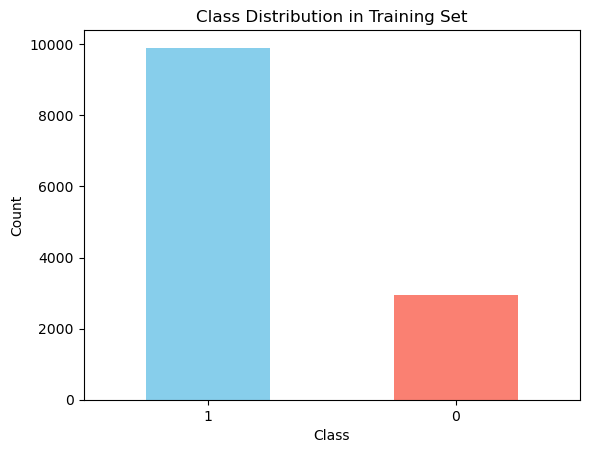

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

train_df['class'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Class Distribution in Training Set')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()


### Most Common Words per Class

In [69]:
from sklearn.feature_extraction.text import CountVectorizer

# Vectorize text
vectorizer = CountVectorizer(stop_words='english', max_features=1000)
X = vectorizer.fit_transform(train_df['clean_text'])

# Combine with labels
word_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names())
word_df['class'] = train_df['class'].values

# Top words in each class
for label in sorted(train_df['class'].unique()):
    print(f"\nTop words for class {label}:")
    class_df = word_df[train_df['class'] == label].drop(columns='class')
    top_words = class_df.sum().sort_values(ascending=False).head(10)
    print(top_words)



Top words for class 0:
know      24949
cooper    21592
mr        18354
davy      13273
said      13137
like      10967
film      10436
year       9055
time       8942
movie      8834
dtype: int64

Top words for class 1:
time      20417
said      20235
year      19309
like      18161
new       17753
season    15329
people    14689
say       11946
day       11680
news      11371
dtype: int64


### Word Clouds per Class

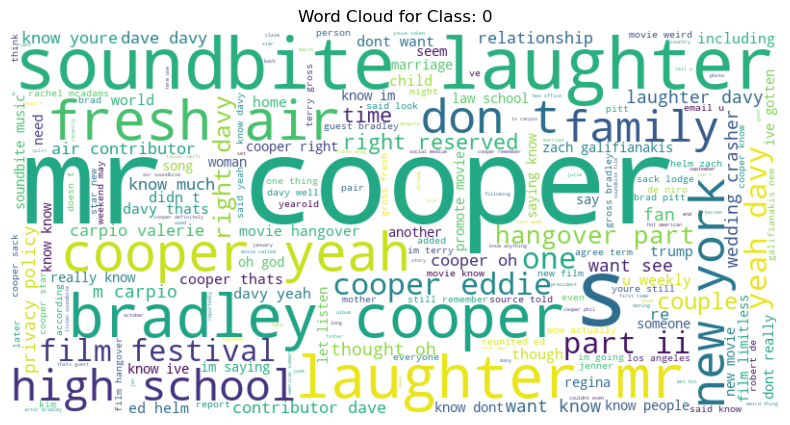

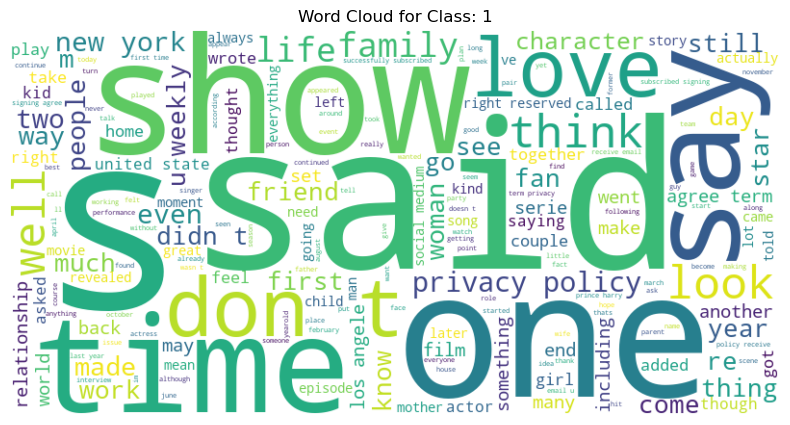

In [70]:
from wordcloud import WordCloud

for label in sorted(train_df['class'].unique()):
    text = ' '.join(train_df[train_df['class'] == label]['clean_text'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for Class: {label}')
    plt.show()


### Most Common Words per Class

In [71]:
from sklearn.feature_extraction.text import CountVectorizer

# Bigram and Trigram
def get_top_ngrams(corpus, ngram_range=(2,2), n=10):
    vec = CountVectorizer(ngram_range=ngram_range, stop_words='english').fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    return sorted(words_freq, key=lambda x: x[1], reverse=True)[:n]

# Top Bigrams
print("Top Bigrams:")
print(get_top_ngrams(train_df['clean_text'], (2, 2)))

# Top Trigrams
print("\nTop Trigrams:")
print(get_top_ngrams(train_df['clean_text'], (3, 3)))


Top Bigrams:
[('mr cooper', 16942), ('new york', 6027), ('privacy policy', 5551), ('soundbite laughter', 4644), ('agree term', 3595), ('right reserved', 3440), ('los angeles', 3324), ('bradley cooper', 3259), ('laughter mr', 3063), ('high school', 2879)]

Top Trigrams:
[('soundbite laughter mr', 3056), ('laughter mr cooper', 3056), ('mr cooper yeah', 2830), ('term privacy policy', 2168), ('signing agree term', 2139), ('agree term privacy', 2128), ('successfully subscribed signing', 2117), ('subscribed signing agree', 2117), ('privacy policy receive', 2117), ('policy receive email', 2117)]


In [72]:
top_bigrams = [('mr cooper', 16942), ('new york', 6027), ('privacy policy', 5551),
               ('soundbite laughter', 4644), ('agree term', 3595), ('right reserved', 3440),
               ('los angeles', 3324), ('bradley cooper', 3259), ('laughter mr', 3063), ('high school', 2879)]

top_trigrams = [('soundbite laughter mr', 3056), ('laughter mr cooper', 3056), ('mr cooper yeah', 2830),
                ('term privacy policy', 2168), ('signing agree term', 2139), ('agree term privacy', 2128),
                ('successfully subscribed signing', 2117), ('subscribed signing agree', 2117),
                ('privacy policy receive', 2117), ('policy receive email', 2117)]


In [73]:
# Convert to DataFrame
bigram_df = pd.DataFrame(top_bigrams, columns=['Bigram', 'Frequency'])
trigram_df = pd.DataFrame(top_trigrams, columns=['Trigram', 'Frequency'])


### Bigram in text visualization

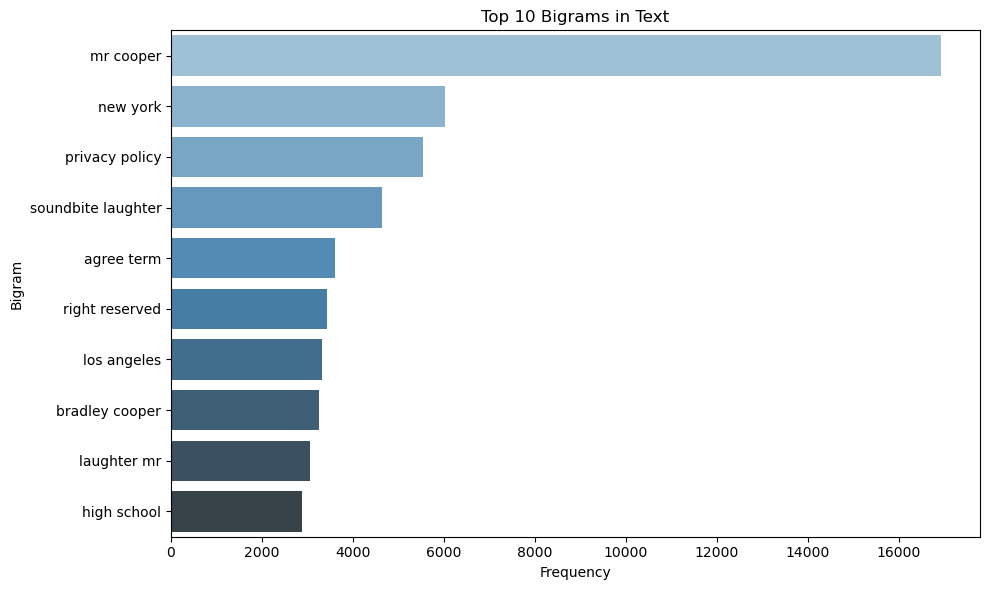

In [74]:
plt.figure(figsize=(10, 6))
sns.barplot(data=bigram_df, y='Bigram', x='Frequency', palette='Blues_d')
plt.title('Top 10 Bigrams in Text')
plt.xlabel('Frequency')
plt.ylabel('Bigram')
plt.tight_layout()
plt.show()


### Trigrams in Text visualization

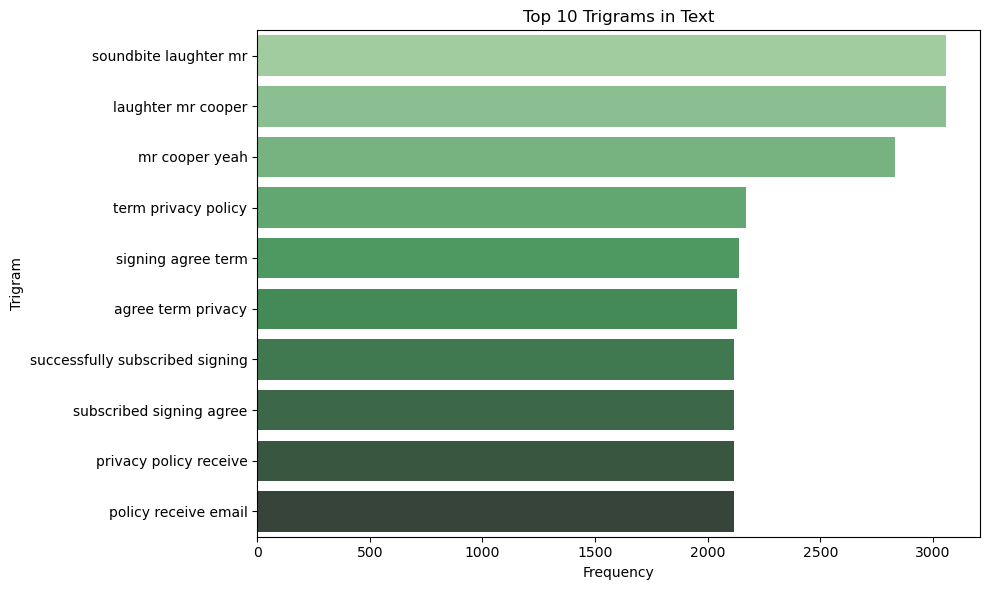

In [75]:
plt.figure(figsize=(10, 6))
sns.barplot(data=trigram_df, y='Trigram', x='Frequency', palette='Greens_d')
plt.title('Top 10 Trigrams in Text')
plt.xlabel('Frequency')
plt.ylabel('Trigram')
plt.tight_layout()
plt.show()


### Logistic Regression Pipeline

In [76]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Logistic Regression Pipeline
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('lr', LogisticRegression(max_iter=200))
])

# Train
lr_pipeline.fit(train_df['clean_text'], train_df['class'])

# Predict
lr_preds = lr_pipeline.predict(test_df['clean_text'])

# Evaluate
print("=== Logistic Regression Report ===")
print(classification_report(test_df['class'], lr_preds))


=== Logistic Regression Report ===
              precision    recall  f1-score   support

           0       0.84      0.45      0.59       734
           1       0.86      0.97      0.91      2475

    accuracy                           0.85      3209
   macro avg       0.85      0.71      0.75      3209
weighted avg       0.85      0.85      0.84      3209



### Class Weighting

Classification Report:

              precision    recall  f1-score   support

           0       0.59      0.71      0.65       734
           1       0.91      0.86      0.88      2475

    accuracy                           0.82      3209
   macro avg       0.75      0.78      0.76      3209
weighted avg       0.84      0.82      0.83      3209



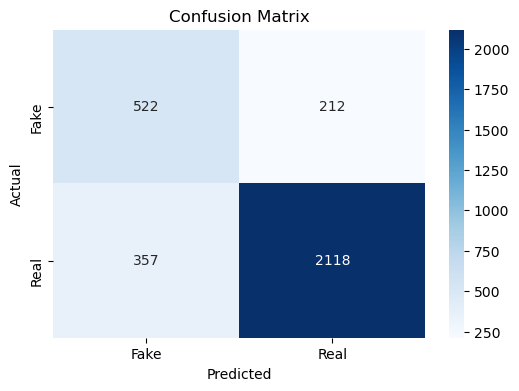

In [77]:
lr_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000)),
    ('lr', LogisticRegression(max_iter=200, class_weight='balanced'))
])

# Fit the model
lr_pipeline.fit(train_df['clean_text'], train_df['class'])

# Predict on test set
y_pred = lr_pipeline.predict(test_df['clean_text'])

# Print classification report
print("Classification Report:\n")
print(classification_report(test_df['class'], y_pred))

# Confusion Matrix
cm = confusion_matrix(test_df['class'], y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


### XGBoost 

In [78]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# Build the pipeline
xgb_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, stop_words='english')),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
])

# Fit the model
xgb_pipeline.fit(train_df['clean_text'], train_df['class'])

# Predict
xgb_preds = xgb_pipeline.predict(test_df['clean_text'])

# Report
print("XGBoost Classification Report ===")
print(classification_report(test_df['class'], xgb_preds))


XGBoost Classification Report ===
              precision    recall  f1-score   support

           0       0.79      0.50      0.61       734
           1       0.87      0.96      0.91      2475

    accuracy                           0.85      3209
   macro avg       0.83      0.73      0.76      3209
weighted avg       0.85      0.85      0.84      3209



### LSTM model

###  Tokenize the Text

In [79]:
# Set a vocabulary size (you can adjust this)
vocab_size = 5000
max_length = 300  # max sequence length for padding

# Initialize and fit the tokenizer
tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['clean_text'])

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(train_df['clean_text'])
X_test_seq = tokenizer.texts_to_sequences(test_df['clean_text'])

# Pad sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post', truncating='post')


### Prepare Labels

In [80]:
y_train = train_df['class'].values
y_test = test_df['class'].values


In [81]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Define the model
model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=300),
    LSTM(128, return_sequences=False),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 300, 64)           320000    
                                                                 
 lstm_1 (LSTM)               (None, 128)               98816     
                                                                 
 dropout_2 (Dropout)         (None, 128)               0         
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dropout_3 (Dropout)         (None, 64)                0         
                                                                 
 dense_3 (Dense)             (None, 1)                 65        
                                                                 
Total params: 427,137
Trainable params: 427,137
Non-tr

In [82]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test_pad, y_test)
)


Epoch 1/5
201/201 [==============================] - 86s 408ms/step - loss: 0.5505 - accuracy: 0.7708 - val_loss: 0.5194 - val_accuracy: 0.7763
Epoch 2/5
201/201 [==============================] - 78s 389ms/step - loss: 0.4908 - accuracy: 0.7934 - val_loss: 0.5065 - val_accuracy: 0.7850
Epoch 3/5
201/201 [==============================] - 78s 390ms/step - loss: 0.4474 - accuracy: 0.8131 - val_loss: 0.5192 - val_accuracy: 0.7778
Epoch 4/5
201/201 [==============================] - 78s 389ms/step - loss: 0.4103 - accuracy: 0.8278 - val_loss: 0.5219 - val_accuracy: 0.7825
Epoch 5/5
201/201 [==============================] - 78s 389ms/step - loss: 0.3816 - accuracy: 0.8339 - val_loss: 0.5263 - val_accuracy: 0.7685


In [83]:
from sklearn.metrics import classification_report, confusion_matrix

# Predict on test set
y_pred_probs = model.predict(X_test_pad)
y_pred = (y_pred_probs > 0.5).astype("int32")

# Evaluation
print("LSTM Classification Report ===")
print(classification_report(y_test, y_pred))


101/101 [==============================] - 10s 97ms/step
LSTM Classification Report ===
              precision    recall  f1-score   support

           0       0.49      0.44      0.47       734
           1       0.84      0.87      0.85      2475

    accuracy                           0.77      3209
   macro avg       0.67      0.65      0.66      3209
weighted avg       0.76      0.77      0.76      3209



Epoch 1/5
201/201 [==============================] - 96s 470ms/step - loss: 0.4716 - accuracy: 0.7744 - val_loss: 0.6561 - val_accuracy: 0.6996
Epoch 2/5
201/201 [==============================] - 86s 430ms/step - loss: 0.4278 - accuracy: 0.8330 - val_loss: 0.7341 - val_accuracy: 0.7361
Epoch 3/5
201/201 [==============================] - 87s 431ms/step - loss: 0.4108 - accuracy: 0.8419 - val_loss: 0.7247 - val_accuracy: 0.7442
Epoch 4/5
201/201 [==============================] - 87s 431ms/step - loss: 0.4444 - accuracy: 0.8089 - val_loss: 0.8169 - val_accuracy: 0.7669
Epoch 5/5
101/101 [==============================] - 11s 108ms/step
Bidirectional LSTM Classification Report ===
              precision    recall  f1-score   support

           0       0.57      0.25      0.35       734
           1       0.81      0.95      0.87      2475

    accuracy                           0.79      3209
   macro avg       0.69      0.60      0.61      3209
weighted avg       0.76      0.79      

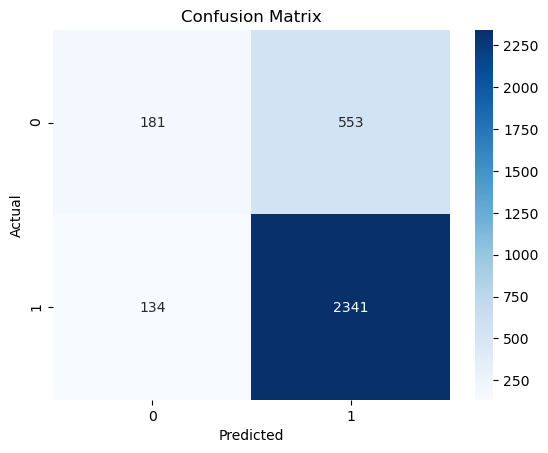

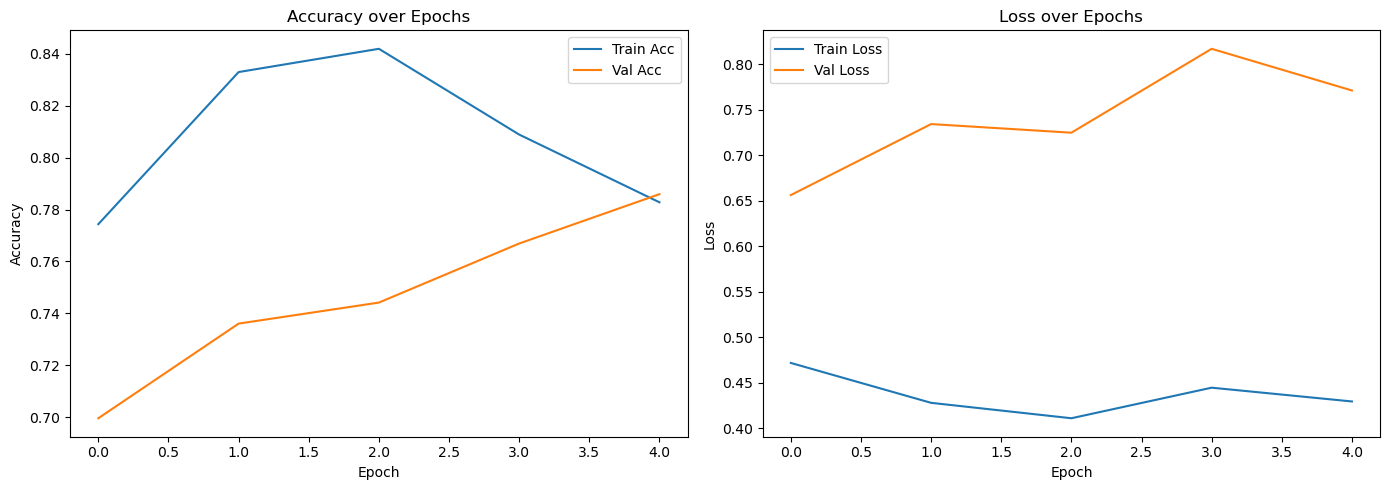

In [84]:
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Compute class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))

# 2. Train the model
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test_pad, y_test),
    class_weight=class_weights
)

# 3. Predict
y_pred_probs = model.predict(X_test_pad)
y_pred = (y_pred_probs > 0.5).astype("int32")

# 4. Evaluation
print("Bidirectional LSTM Classification Report ===")
print(classification_report(y_test, y_pred))

# 5. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 6. Optional: Accuracy & Loss plot
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()


In [85]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

CUDA available: False
Device: CPU


In [86]:
import pandas as pd

# Replace with your actual dataset path
df = pd.read_csv('../dataset/data.csv')
print("Dataset size:", len(df))
print("Columns:", df.columns)
print("Head:\n", df.head())
print("Info:\n", df.info())
print("Label distribution:\n", df['class'].value_counts())

Dataset size: 16044
Columns: Index(['news_url', 'title', 'extracted_article_text', 'news_type', 'class'], dtype='object')
Head:
                                             news_url  \
0  https://www.bustle.com/p/will-the-royals-retur...   
1  https://www.foxnews.com/entertainment/naya-riv...   
2  https://www.unitedbypop.com/style/fashion/tayl...   
3  https://variety.com/2018/music/news/scott-hutc...   
4  https://www.etonline.com/kate-middleton-gives-...   

                                               title  \
0  Will 'The Royals' Return For Season 5? This St...   
1  Naya Rivera refiles for divorce from Ryan Dors...   
2    Outfit ideas for Taylor Swift's Reputation Tour   
3  Scott Hutchison Dead: Frightened Rabbit Frontm...   
4  Kate Middleton Gives Birth to Royal Baby No. 3...   

                              extracted_article_text news_type  class  
0  Entertainment With a royal wedding and a coup ...    gossip      1  
1  This material may not be published, broadcast,... 

In [88]:
df = pd.read_csv('../dataset/data.csv')
df.head(5)

,news_url,title,extracted_article_text,news_type,class
0,https://www.bustle.com/p/will-the-royals-retur...,Will 'The Royals' Return For Season 5? This St...,Entertainment With a royal wedding and a coup ...,gossip,1
1,https://www.foxnews.com/entertainment/naya-riv...,Naya Rivera refiles for divorce from Ryan Dors...,"This material may not be published, broadcast,...",gossip,1
2,https://www.unitedbypop.com/style/fashion/tayl...,Outfit ideas for Taylor Swift's Reputation Tour,United By Pop - United Kingdom. United States....,gossip,1
3,https://variety.com/2018/music/news/scott-hutc...,Scott Hutchison Dead: Frightened Rabbit Frontm...,By Robert Mitchell A body found Thursday night...,gossip,1
4,https://www.etonline.com/kate-middleton-gives-...,Kate Middleton Gives Birth to Royal Baby No. 3...,Baby No. 3 is officially here! Kate Middleton ...,gossip,1


In [89]:
df.head(5)

,news_url,title,extracted_article_text,news_type,class
0,https://www.bustle.com/p/will-the-royals-retur...,Will 'The Royals' Return For Season 5? This St...,Entertainment With a royal wedding and a coup ...,gossip,1
1,https://www.foxnews.com/entertainment/naya-riv...,Naya Rivera refiles for divorce from Ryan Dors...,"This material may not be published, broadcast,...",gossip,1
2,https://www.unitedbypop.com/style/fashion/tayl...,Outfit ideas for Taylor Swift's Reputation Tour,United By Pop - United Kingdom. United States....,gossip,1
3,https://variety.com/2018/music/news/scott-hutc...,Scott Hutchison Dead: Frightened Rabbit Frontm...,By Robert Mitchell A body found Thursday night...,gossip,1
4,https://www.etonline.com/kate-middleton-gives-...,Kate Middleton Gives Birth to Royal Baby No. 3...,Baby No. 3 is officially here! Kate Middleton ...,gossip,1
